This notebook took code from Word2vec | Text (2024) and X. Refer to those tutorials for thorough explanation of cells.


References

Gil, M. (2021, June 27). Using Word Embeddings with TensorFlow for Movie Review Text Classification. Medium; Chatbots Life. https://blog.chatbotslife.com/using-word-embeddings-with-tensorflow-for-movie-review-text-classification-6c943d14cca2

Word embeddings. (2024). TensorFlow. https://www.tensorflow.org/text/tutorials/word_embeddings#using_the_embedding_layer

word2vec | Text. (2024, July 19). TensorFlow. https://www.tensorflow.org/text/tutorials/word2vec

# Setup

In [2]:
import io
import re
import string
import tqdm

import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers

In [3]:
# Load the TensorBoard notebook extension
%load_ext tensorboard

# generate_training_data
Create the skip-gram pairs for the sequences to be used for creating the dataset for training the word embedding.

In [4]:
# Generates skip-gram pairs with negative sampling for a list of sequences
# (int-encoded sentences) based on window size, number of negative samples
# and vocabulary size.
def generate_training_data(sequences, window_size, num_ns, vocab_size, seed):

  # Set the random seed for reproducibility.
  seed = 42 if seed is None else int(seed)

  # Elements of each training example are appended to these lists.
  targets, contexts, labels = [], [], []

  # Build the sampling table for `vocab_size` tokens.
  sampling_table = tf.keras.preprocessing.sequence.make_sampling_table(vocab_size)

  # Iterate over all sequences (sentences) in the dataset.
  for sequence in tqdm.tqdm(sequences):

    # Generate positive skip-gram pairs for a sequence (sentence).
    positive_skip_grams, _ = tf.keras.preprocessing.sequence.skipgrams(
          sequence,
          vocabulary_size=vocab_size,
          sampling_table=sampling_table,
          window_size=window_size,
          negative_samples=0,
          # skips Keras's internal shuffling of skip-gram pairs, which is not needed as we will shuffle later on in `tf.data.Dataset.shuffle(10000)` plus there was a potential issue with seed being treated as a float but failing as it expects an int.
          shuffle=False, 
    )

    # Iterate over each positive skip-gram pair to produce training examples
    # with a positive context word and negative samples.
    for target_word, context_word in positive_skip_grams:
      context_class = tf.expand_dims(
          tf.constant([context_word], dtype="int64"), 1)
      negative_sampling_candidates, _, _ = tf.random.log_uniform_candidate_sampler(
          true_classes=context_class,
          num_true=1,
          num_sampled=num_ns,
          unique=True,
          range_max=vocab_size,
          seed=seed,
          name="negative_sampling")

      # Build context and label vectors (for one target word)
      context = tf.concat([tf.squeeze(context_class,1), negative_sampling_candidates], 0)
      label = tf.constant([1] + [0]*num_ns, dtype="int64")

      # Append each element from the training example to global lists.
      targets.append(target_word)
      contexts.append(context)
      labels.append(label)

  return targets, contexts, labels

# Shakespeare dataset
Prepare data from large corpus - shakespeare

In [5]:
path_to_file = tf.keras.utils.get_file('shakespeare.txt', 'https://storage.googleapis.com/download.tensorflow.org/data/shakespeare.txt')

1115394/1115394 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [6]:
with open(path_to_file) as f:
  lines = f.read().splitlines()
for line in lines[:20]:
  print(line)

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.


In [7]:
SEED = 42
AUTOTUNE = tf.data.AUTOTUNE

# Create a `TextLineDataset` and filter out empty lines.
text_ds = tf.data.TextLineDataset(path_to_file).filter(lambda x: tf.cast(tf.strings.length(x), bool))

# Now, create a custom standardization function to lowercase the text and
# remove punctuation.
def custom_standardization(input_data):
  lowercase = tf.strings.lower(input_data)
  return tf.strings.regex_replace(lowercase,
                                  '[%s]' % re.escape(string.punctuation), '')


# Define the vocabulary size and the number of words in a sequence.
vocab_size = 4096
sequence_length = 10

# Use the `TextVectorization` layer to normalize, split, and map strings to
# integers. Set the `output_sequence_length` length to pad all samples to the
# same length.
vectorize_layer = layers.TextVectorization(
    standardize=custom_standardization,
    max_tokens=vocab_size,
    output_mode='int',
    output_sequence_length=sequence_length)

# create vocabulary by calling adapt on the text dataset. This will also convert the text dataset into integer sequences. The text dataset is batched to speed up the process of creating the vocabulary.
vectorize_layer.adapt(text_ds.batch(1024))

# Save the created vocabulary for reference.
inverse_vocab = vectorize_layer.get_vocabulary()
print(f"inverse vocabulary size: {len(inverse_vocab)}")
print(inverse_vocab[:20])

# Vectorize the data in text_ds.
text_vector_ds = text_ds.batch(1024).prefetch(AUTOTUNE).map(vectorize_layer).unbatch()

sequences = list(text_vector_ds.as_numpy_iterator())
print(f"Number of sequences: {len(sequences)}")
print(len(sequences))

print(f"First 5 sequences: {sequences[:5]}")
for seq in sequences[:5]:
  print(f"{seq} => {[inverse_vocab[i] for i in seq]}")

targets, contexts, labels = generate_training_data(
    sequences=sequences,
    window_size=2,
    num_ns=4,
    vocab_size=vocab_size,
    seed=SEED)

targets = np.array(targets)
contexts = np.array(contexts)
labels = np.array(labels)

print(f"Number of training examples: {len(targets)}")
print('\n')
print(f"targets.shape: {targets.shape}")
print(f"contexts.shape: {contexts.shape}")
print(f"labels.shape: {labels.shape}")


BATCH_SIZE = 1024
BUFFER_SIZE = 10000
dataset = tf.data.Dataset.from_tensor_slices(((targets, contexts), labels))
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)
print(f"Number of batches or size of dataset: {len(dataset)}")
print(dataset)

# print(f"First batch of targets: {targets[:BATCH_SIZE]}")
print('dataset cache and prefetch')
dataset = dataset.cache().prefetch(buffer_size=AUTOTUNE)
print(dataset)


inverse vocabulary size: 4096
['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('to'), np.str_('i'), np.str_('of'), np.str_('you'), np.str_('my'), np.str_('a'), np.str_('that'), np.str_('in'), np.str_('is'), np.str_('not'), np.str_('for'), np.str_('with'), np.str_('me'), np.str_('it'), np.str_('be'), np.str_('your')]
Number of sequences: 32777
32777
First 5 sequences: [array([ 89, 270,   0,   0,   0,   0,   0,   0,   0,   0]), array([138,  36, 982, 144, 673, 125,  16, 106,   0,   0]), array([34,  0,  0,  0,  0,  0,  0,  0,  0,  0]), array([106, 106,   0,   0,   0,   0,   0,   0,   0,   0]), array([ 89, 270,   0,   0,   0,   0,   0,   0,   0,   0])]
[ 89 270   0   0   0   0   0   0   0   0] => [np.str_('first'), np.str_('citizen'), '', '', '', '', '', '', '', '']
[138  36 982 144 673 125  16 106   0   0] => [np.str_('before'), np.str_('we'), np.str_('proceed'), np.str_('any'), np.str_('further'), np.str_('hear'), np.str_('me'), np.str_('speak'), '', '']
[34  0  0  0  0  0  0  0  0  

100%|██████████| 32777/32777 [00:20<00:00, 1562.32it/s]


Number of training examples: 65269


targets.shape: (65269,)
contexts.shape: (65269, 5)
labels.shape: (65269, 5)
Number of batches or size of dataset: 63
<_BatchDataset element_spec=((TensorSpec(shape=(1024,), dtype=tf.int64, name=None), TensorSpec(shape=(1024, 5), dtype=tf.int64, name=None)), TensorSpec(shape=(1024, 5), dtype=tf.int64, name=None))>
dataset cache and prefetch
<_PrefetchDataset element_spec=((TensorSpec(shape=(1024,), dtype=tf.int64, name=None), TensorSpec(shape=(1024, 5), dtype=tf.int64, name=None)), TensorSpec(shape=(1024, 5), dtype=tf.int64, name=None))>


# Word2Vec & Training

In [8]:
class Word2Vec(tf.keras.Model):
  def __init__(self, vocab_size, embedding_dim):
    super(Word2Vec, self).__init__()
    self.target_embedding = layers.Embedding(vocab_size,
                                      embedding_dim,
                                      name="w2v_embedding")
    self.context_embedding = layers.Embedding(vocab_size, embedding_dim)

  def call(self, pair):
    target, context = pair
    # target: (batch, dummy?)  # The dummy axis doesn't exist in TF2.7+
    # context: (batch, context)
    if len(target.shape) == 2:
      target = tf.squeeze(target, axis=1)
    # target: (batch,)
    word_emb = self.target_embedding(target)
    # word_emb: (batch, embed)
    context_emb = self.context_embedding(context)
    # context_emb: (batch, context, embed)
    dots = tf.einsum('be,bce->bc', word_emb, context_emb)
    # dots: (batch, context)
    return dots
  
def custom_loss(x_logit, y_true):
  return tf.nn.sigmoid_cross_entropy_with_logits(logits=x_logit, labels=y_true)

embedding_dim = 128
word2vec = Word2Vec(vocab_size, embedding_dim)
word2vec.compile(
  optimizer='adam',
  loss=tf.keras.losses.CategoricalCrossentropy(from_logits=True),
  metrics=['accuracy']
)


tensorboard_callback = tf.keras.callbacks.TensorBoard(log_dir="logs")

# word2vec.fit(dataset, epochs=20, callbacks=[tensorboard_callback])
word2vec.fit(dataset, epochs=1, callbacks=[tensorboard_callback])



63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.2341 - loss: 1.6081


# Custom - Multi-Epoch, Tests & Accuracy vs Loss Plots

In [9]:
# max_epochs = 4
max_epochs = 20
last_epoch = max_epochs-1
w2v_history = word2vec.fit(dataset, epochs=max_epochs, callbacks=[tensorboard_callback])
print(w2v_history.params)

# final training accuracy (last epoch) in q5_final_train_acc (float, rounded to 3 decimals).
# ref https://apxml.com/courses/deep-learning-fundamentals-keras/chapter-3-training-deep-neural-networks/validation-data-monitoring
# history.history has the metrics. Could not find this obvious in the keras or tensorflow docs so found it in a
# random article online unfortunately.
# got intitial: "AssertionError: History should contain 'val_accuracy'. Did you pass validation_data to fit()?"
print(w2v_history.history.keys())
print(w2v_history.history)
print(len(w2v_history.history.get('accuracy')))
print(w2v_history.history.get('accuracy')[last_epoch])

final_train_acc = float(round(w2v_history.history.get('accuracy')[last_epoch], 3))

Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.5514 - loss: 1.5838
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5648 - loss: 1.5163
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.5413 - loss: 1.4258
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5685 - loss: 1.3300
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.6076 - loss: 1.2364
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6469 - loss: 1.1488
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6828 - loss: 1.0674
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7149 - loss: 0.9918
Epoch 9/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.7436 - loss: 0.9218
Epoch 10/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7668 - loss: 0.8570
Epoch 11/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7888 - loss: 0.7972
Epoch 12/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.

In [10]:
def tests_for_history(history, final_train_acc):
  assert hasattr(history, 'history'), (
      "history should be a Keras History object. Did you call model.fit()?"
  )
  assert 'accuracy' in history.history, (
      "History should contain 'accuracy'. Did you include metrics=['accuracy'] in compile?"
  )
  # TODO: consider validation data on fit to measure val_accuracy as well and add to the tests.
  # assert 'val_accuracy' in history.history, (
  #     "History should contain 'val_accuracy'. Did you pass validation_data to fit()?"
  # )

  assert isinstance(final_train_acc, float), (
      "final_train_acc must be a float."
  )
  assert 0 <= final_train_acc <= 1, (
      "Accuracy must be between 0 and 1."
  )
  print(f"Final training accuracy: {final_train_acc:.3f}")

tests_for_history(w2v_history, final_train_acc)

Final training accuracy: 0.901


## Plots

There is an inverse relationship between loss and accuracy (as loss drops, accuracy increases), which is what we want to see. 

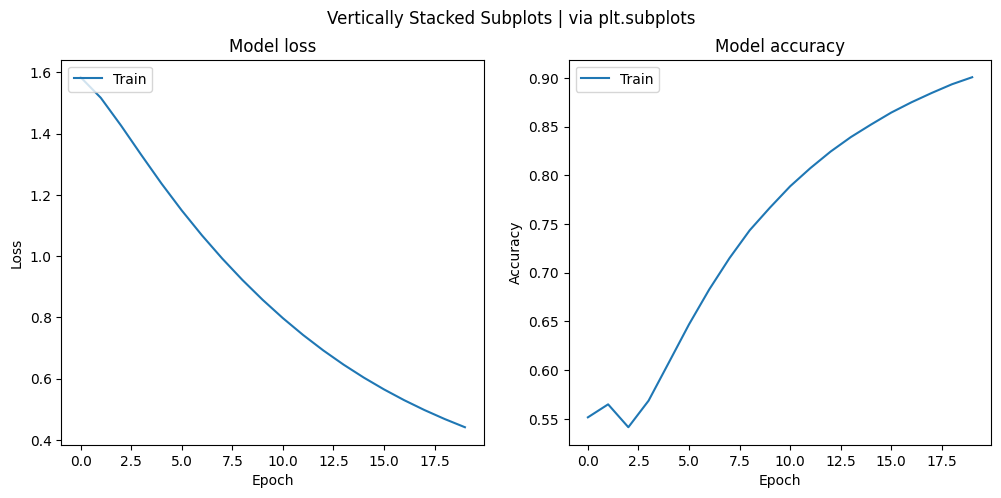

In [11]:
accuracy = w2v_history.history.get('accuracy')
loss = w2v_history.history.get('loss')
# val_accuracy = w2v_history.history.get('val_accuracy')
# val_loss = w2v_history.history.get('val_loss')

# fig 2
fig = plt.figure(2, figsize=(12, 5))
ax1, ax2 = fig.subplots(1, 2)
# or just one liner but i could not confirm kwargs to figure in docs but does work??
# prefer the above as it splits it better.
# fig, (ax1, ax2) = plt.subplots(1, 2, num=2, figsize=(12, 5))
    
    
# Left subplot: Training and validation loss over epochs
    
# Plot training & validation loss values
# ax1.subplot(1, 2, 2)
ax1.plot(loss)
# ax1.plot(val_loss)
ax1.set_title('Model loss')
ax1.set_ylabel('Loss')
ax1.set_xlabel('Epoch')
ax1.legend(['Train'], loc='upper left')

    
# Right subplot: Training and validation accuracy over epochs

# plt.subplot(1, 2, 1)
ax2.plot(accuracy)
# ax2.plot(val_accuracy)
ax2.set_title('Model accuracy')
ax2.set_ylabel('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend(['Train'], loc='upper left')

# Add a title to the entire figure
fig.suptitle('Vertically Stacked Subplots | via plt.subplots')

# Adjust layout
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Display the figure
plt.show()

# Get Embedding Weights & Vocab for Classification

In [12]:
weights = word2vec.get_layer('w2v_embedding').get_weights()[0]
vocab = vectorize_layer.get_vocabulary()

print(f"Embedding shape: {weights.shape}")
print(f"Vocabulary size: {len(vocab)}")
print(f"First 10 words in the vocabulary: {vocab[:10]}")

Embedding shape: (4096, 128)
Vocabulary size: 4096
First 10 words in the vocabulary: ['', '[UNK]', np.str_('the'), np.str_('and'), np.str_('to'), np.str_('i'), np.str_('of'), np.str_('you'), np.str_('my'), np.str_('a')]


# Classification Task

In [17]:
from pathlib import Path
import tarfile

# Download archive to a writable project-local cache and extract explicitly.
imdb_cache_dir = Path.cwd() / ".tf_data"
imdb_cache_dir.mkdir(parents=True, exist_ok=True)

dataset_archive = Path(tf.keras.utils.get_file(
    fname="aclImdb_v1.tar.gz",
    origin="https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz",
    cache_dir=str(imdb_cache_dir),
    cache_subdir="",
    extract=False,
))

dataset_dir = imdb_cache_dir / "aclImdb"
if not dataset_dir.exists():
    with tarfile.open(dataset_archive, "r:gz") as tar:
        tar.extractall(path=imdb_cache_dir)

if not dataset_dir.exists():
    raise FileNotFoundError(f"IMDB dataset directory not found after extraction: {dataset_dir}")

train_dir = dataset_dir / "train"
test_dir = dataset_dir / "test"

print(f"Dataset archive: {dataset_archive}")
print(f"Dataset directory: {dataset_dir}")
print(f"Using pretrained embedding matrix shape: {weights.shape}")
print(f"Using pretrained vocabulary size: {len(vocab)}")

84125825/84125825 ━━━━━━━━━━━━━━━━━━━━ 19s 0us/step


/tmp/ipykernel_5959/1065336488.py:19: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=imdb_cache_dir)


Dataset archive: /content/.tf_data/aclImdb_v1.tar.gz
Dataset directory: /content/.tf_data/aclImdb
Using pretrained embedding matrix shape: (4096, 128)
Using pretrained vocabulary size: 4096


In [18]:
def make_labeled_review_ds(split_dir, shuffle=False):
    if not split_dir.exists():
        raise FileNotFoundError(f"Split directory does not exist: {split_dir}")

    pos_files = sorted((split_dir / "pos").glob("*.txt"))
    neg_files = sorted((split_dir / "neg").glob("*.txt"))

    file_paths = [str(path) for path in pos_files + neg_files]
    labels = [1] * len(pos_files) + [0] * len(neg_files)

    if not file_paths:
        raise ValueError(
            f"No review files found under {split_dir}. Expected pos/*.txt and neg/*.txt."
        )

    ds = tf.data.Dataset.from_tensor_slices((file_paths, labels))
    if shuffle and len(file_paths) > 1:
        ds = ds.shuffle(len(file_paths), seed=SEED, reshuffle_each_iteration=False)

    ds = ds.map(
        lambda path, label: (tf.io.read_file(path), tf.cast(label, tf.float32)),
        num_parallel_calls=AUTOTUNE,
    )
    return ds

full_train_ds = make_labeled_review_ds(train_dir, shuffle=True)
test_ds = make_labeled_review_ds(test_dir, shuffle=False)

In [ ]:

# Split training into train/validation.
val_size = 5000
val_ds = full_train_ds.take(val_size)
train_ds = full_train_ds.skip(val_size)

BATCH_SIZE = 64
train_ds = train_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = test_ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# Reuse the same learned vocabulary ordering so embedding rows still align with tokens.
review_sequence_length = 200
review_vectorizer = layers.TextVectorization(
    standardize=custom_standardization,
    output_mode="int",
    output_sequence_length=review_sequence_length,
    vocabulary=vocab,
)

classifier = tf.keras.Sequential([
    review_vectorizer,
    layers.Embedding(
        input_dim=len(vocab),
        output_dim=weights.shape[1],
        embeddings_initializer=tf.keras.initializers.Constant(weights),
        trainable=False,
        mask_zero=True,
        name="pretrained_embedding",
    ),
    layers.GlobalAveragePooling1D(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(1, activation="sigmoid"),
])

classifier.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

classifier.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
    )
]

classification_history = classifier.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    callbacks=callbacks,
)

test_loss, test_acc, test_auc = classifier.evaluate(test_ds, verbose=1)
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

# Quick sanity-check predictions.
sample_reviews = tf.constant([
    "this movie was excellent and emotionally engaging",
    "the plot was dull and the acting was terrible",
    "it started slowly but became quite moving by the end",
])

sample_probs = classifier.predict(sample_reviews, verbose=0).flatten()
for review, prob in zip(sample_reviews.numpy(), sample_probs):
    print(f"{prob:.3f} :: {review.decode('utf-8')}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ text_vectorization_1            │ ?                      │   0 (unbuilt) │
│ (TextVectorization)             │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ pretrained_embedding            │ ?                      │   0 (unbuilt) │
│ (Embedding)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5505 - auc: 0.5758 - loss: 0.6864 - val_accuracy: 0.5814 - val_auc: 0.6407 - val_loss: 0.6787
Epoch 2/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6012 - auc: 0.6410 - loss: 0.6693 - val_accuracy: 0.6208 - val_auc: 0.6721 - val_loss: 0.6606
Epoch 3/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.6240 - auc: 0.6707 - loss: 0.6524 - val_accuracy: 0.6358 - val_auc: 0.6910 - val_loss: 0.6465
Epoch 4/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.6382 - auc: 0.6893 - loss: 0.6406 - val_accuracy: 0.6414 - val_auc: 0.7047 - val_loss: 0.6355
Epoch 5/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.6439 - auc: 0.6997 - loss: 0.6322 - val_accuracy: 0.6510 - val_auc: 0.7133 - val_loss: 0.6287
Epoch 6/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - accuracy: 0.6502 - auc: 0.7076 - loss: 0.6267 - val_accuracy: 0.6574 - val_auc: 0.7192 - val_loss: 0.6220
Epoch 7/8
313/313 ━━━━━━━━━━━━━━━━━━━━ 5

## Evaluation & Plotting

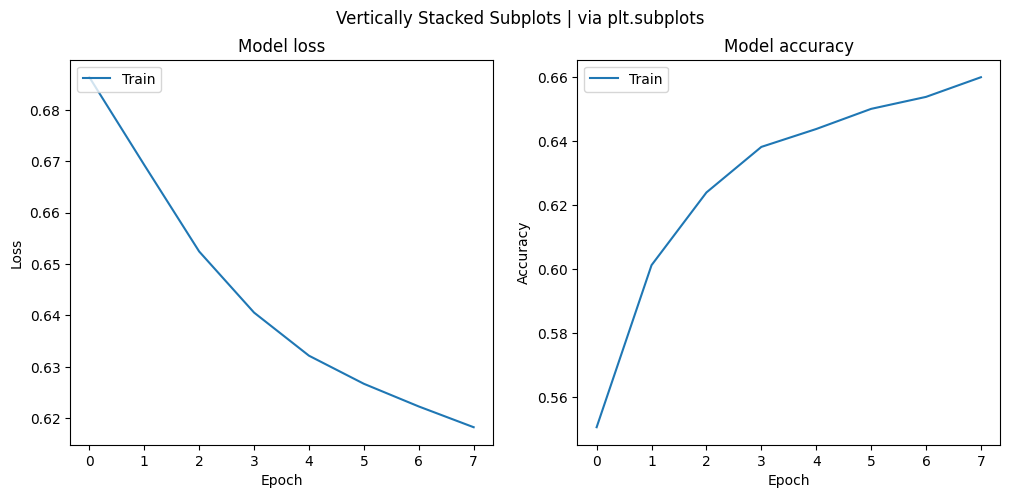

In [20]:
class_accuracy = classification_history.history.get('accuracy')
class_loss = classification_history.history.get('loss')
# val_accuracy = classification_history.history.get('val_accuracy')
# val_loss = classification_history.history.get('val_loss')

# fig 2
fig = plt.figure(2, figsize=(12, 5))
ax1, ax2 = fig.subplots(1, 2)
# or just one liner but i could not confirm kwargs to figure in docs but does work??
# prefer the above as it splits it better.
# fig, (ax1, ax2) = plt.subplots(1, 2, num=2, figsize=(12, 5))
    
    
# Left subplot: Training and validation loss over epochs
    
# Plot training & validation loss values
# ax1.subplot(1, 2, 2)
ax1.plot(class_loss)
# ax1.plot(val_loss)
ax1.set_title('Model loss')
ax1.set_ylabel('Loss')
ax1.set_xlabel('Epoch')
ax1.legend(['Train'], loc='upper left')

    
# Right subplot: Training and validation accuracy over epochs

# plt.subplot(1, 2, 1)
ax2.plot(class_accuracy)
# ax2.plot(val_accuracy)
ax2.set_title('Model accuracy')
ax2.set_ylabel('Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend(['Train'], loc='upper left')

# Add a title to the entire figure
fig.suptitle('Vertically Stacked Subplots | via plt.subplots')

# Adjust layout
# plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Display the figure
plt.show()

In [21]:
threshold = 0.5
uncertainty_margin = 0.10  # 0.40 to 0.60 is treated as uncertain

sample_reviews = tf.constant([
    "this movie was excellent and emotionally engaging",
    "the plot was dull and the acting was terrible",
    "it started slowly but became quite moving by the end",
])

probs = classifier.predict(sample_reviews, verbose=0).flatten()

print("prob_pos | prob_neg | pred_label | confidence | review")
print("-" * 95)

for review, p in zip(sample_reviews.numpy(), probs):
    p = float(p)
    pred_label = "positive" if p >= threshold else "negative"

    # Confidence bucket based on distance from 0.5
    distance = abs(p - 0.5)
    if distance >= 0.40:
        confidence = "very high"
    elif distance >= 0.25:
        confidence = "high"
    elif distance >= 0.10:
        confidence = "medium"
    else:
        confidence = "low/uncertain"

    # Optional explicit uncertainty zone
    uncertain = (threshold - uncertainty_margin) <= p <= (threshold + uncertainty_margin)
    uncertainty_flag = " (uncertain)" if uncertain else ""

    print(f"{p:7.3f} | {1-p:8.3f} | {pred_label:10s} | {confidence:12s} | {review.decode('utf-8')}{uncertainty_flag}")

prob_pos | prob_neg | pred_label | confidence | review
-----------------------------------------------------------------------------------------------
  0.592 |    0.408 | positive   | low/uncertain | this movie was excellent and emotionally engaging (uncertain)
  0.183 |    0.817 | negative   | high         | the plot was dull and the acting was terrible
  0.286 |    0.714 | negative   | medium       | it started slowly but became quite moving by the end


Confusion Matrix (rows=true, cols=pred)
                pred_neg   pred_pos
true_neg (0)        7449       5051
true_pos (1)        3423       9077

Threshold: 0.50
Accuracy : 0.6610
Precision: 0.6425
Recall   : 0.7262
F1 score : 0.6818


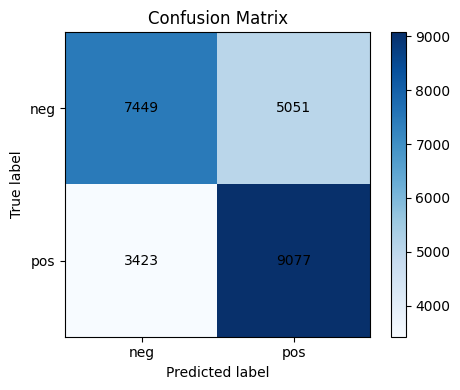

In [22]:
threshold = 0.5

y_true_batches = []
y_prob_batches = []

for x_batch, y_batch in test_ds:
    y_prob = classifier.predict(x_batch, verbose=0).reshape(-1)
    y_true_batches.append(y_batch.numpy().reshape(-1))
    y_prob_batches.append(y_prob)

y_true = np.concatenate(y_true_batches).astype(np.int32)
y_prob = np.concatenate(y_prob_batches)
y_pred = (y_prob >= threshold).astype(np.int32)

tp = int(np.sum((y_true == 1) & (y_pred == 1)))
tn = int(np.sum((y_true == 0) & (y_pred == 0)))
fp = int(np.sum((y_true == 0) & (y_pred == 1)))
fn = int(np.sum((y_true == 1) & (y_pred == 0)))

eps = 1e-8
accuracy = (tp + tn) / max(len(y_true), 1)
precision = tp / max(tp + fp, 1)
recall = tp / max(tp + fn, 1)
f1 = 2 * precision * recall / max(precision + recall, eps)

print("Confusion Matrix (rows=true, cols=pred)")
print("                pred_neg   pred_pos")
print(f"true_neg (0)    {tn:8d}   {fp:8d}")
print(f"true_pos (1)    {fn:8d}   {tp:8d}")
print()
print(f"Threshold: {threshold:.2f}")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 score : {f1:.4f}")

# Optional: quick heatmap
cm = np.array([[tn, fp], [fn, tp]])
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111)
im = ax.imshow(cm, cmap="Blues")
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted label")
ax.set_ylabel("True label")
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(["neg", "pos"])
ax.set_yticklabels(["neg", "pos"])

for i in range(2):
    for j in range(2):
        ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

In [23]:
# Threshold sweep on the already-computed y_true / y_prob from your confusion-matrix cell
thresholds = np.arange(0.1, 0.91, 0.05)

rows = []
for t in thresholds:
    y_pred_t = (y_prob >= t).astype(np.int32)

    tp = int(np.sum((y_true == 1) & (y_pred_t == 1)))
    tn = int(np.sum((y_true == 0) & (y_pred_t == 0)))
    fp = int(np.sum((y_true == 0) & (y_pred_t == 1)))
    fn = int(np.sum((y_true == 1) & (y_pred_t == 0)))

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-8)
    accuracy = (tp + tn) / max(len(y_true), 1)

    rows.append((t, accuracy, precision, recall, f1, tp, fp, fn, tn))

print("thr | acc    | prec   | rec    | f1     | tp   fp   fn   tn")
print("-" * 72)
for r in rows:
    print(f"{r[0]:.2f} | {r[1]:.4f} | {r[2]:.4f} | {r[3]:.4f} | {r[4]:.4f} | {r[5]:4d} {r[6]:4d} {r[7]:4d} {r[8]:4d}")

best_f1 = max(rows, key=lambda x: x[4])
print("\nBest threshold by F1:")
print(f"threshold={best_f1[0]:.2f}, F1={best_f1[4]:.4f}, precision={best_f1[2]:.4f}, recall={best_f1[3]:.4f}")

thr | acc    | prec   | rec    | f1     | tp   fp   fn   tn
------------------------------------------------------------------------
0.10 | 0.5009 | 0.5005 | 1.0000 | 0.6671 | 12500 12477    0   23
0.15 | 0.5029 | 0.5015 | 0.9992 | 0.6678 | 12490 12417   10   83
0.20 | 0.5126 | 0.5064 | 0.9964 | 0.6715 | 12455 12140   45  360
0.25 | 0.5324 | 0.5170 | 0.9861 | 0.6783 | 12326 11516  174  984
0.30 | 0.5602 | 0.5333 | 0.9648 | 0.6869 | 12060 10556  440 1944
0.35 | 0.5916 | 0.5547 | 0.9286 | 0.6946 | 11608 9317  892 3183
0.40 | 0.6249 | 0.5827 | 0.8800 | 0.7011 | 11000 7878 1500 4622
0.45 | 0.6487 | 0.6119 | 0.8134 | 0.6984 | 10168 6450 2332 6050
0.50 | 0.6610 | 0.6425 | 0.7262 | 0.6818 | 9077 5051 3423 7449
0.55 | 0.6656 | 0.6801 | 0.6255 | 0.6517 | 7819 3678 4681 8822
0.60 | 0.6563 | 0.7184 | 0.5142 | 0.5994 | 6427 2519 6073 9981
0.65 | 0.6353 | 0.7538 | 0.4019 | 0.5243 | 5024 1641 7476 10859
0.70 | 0.6037 | 0.7897 | 0.2827 | 0.4164 | 3534  941 8966 11559
0.75 | 0.5686 | 0.8353 | 0.1708 |

From AI gen GPT 5.3-codex

How to interpret your current outputs:

Confusion matrix
true_neg: actual negative reviews predicted negative (good).
false_pos: actual negative predicted positive (bad, “false alarm”).
false_neg: actual positive predicted negative (bad, “missed positive”).
true_pos: actual positive predicted positive (good).
Accuracy
Fraction of all predictions that are correct.
Can look good even if one class is favored, so do not use alone.
Precision
Of all predicted positive reviews, how many were truly positive.
High precision means fewer false positives.
Recall
Of all truly positive reviews, how many you caught.
High recall means fewer false negatives.
F1
Balance between precision and recall.
Best single metric when you care about both.
AUC (from your training/eval cell at word_embeddings_classification.ipynb:584)
Measures ranking quality across all thresholds.
Closer to 1.0 is better; 0.5 is random.
How threshold changes behavior:

Lower threshold (for example 0.3): more positives predicted, recall usually up, precision usually down.
Higher threshold (for example 0.7): fewer positives predicted, precision usually up, recall usually down.
Pick threshold by goal:
Minimize false negatives: prefer higher recall (lower threshold).
Minimize false positives: prefer higher precision (higher threshold).
Balanced: use best F1 threshold.
One extra caution for your notebook:

Since embeddings were pretrained on Shakespeare, modern IMDB language mismatch can reduce reliability, so use test metrics and threshold tuning rather than trusting raw probability confidence alone.